In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Housing.csv')

# First 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
# Dataset shape
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Rows and Columns: (545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Convert yes/no columns to numeric
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning',
               'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encoding for furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("New Shape:", df.shape)
df.head()

New Shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [6]:
import pandas as pd

df = pd.read_csv("Housing.csv")

# Convert yes/no columns
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning',
               'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [7]:
import os
print(os.listdir())

['.config', 'Housing.csv', 'sample_data']


In [8]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop("price", axis=1)
y = df["price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 970043.4039201637
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153185


In [10]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MAE: 1022560.0527522935
RMSE: 1401496.8425384816
R2 Score: 0.6114024924156645


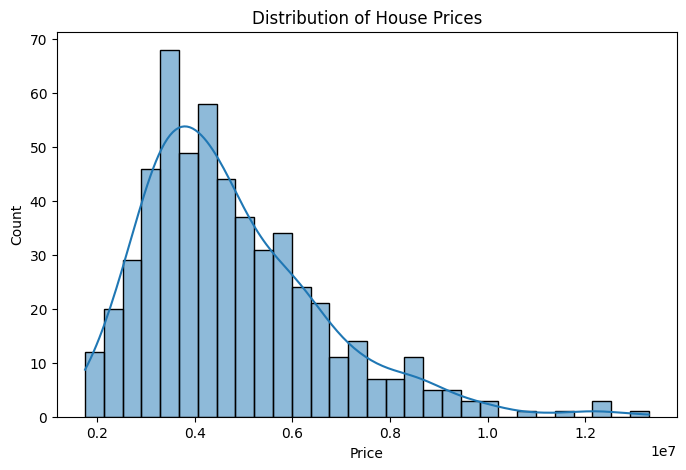

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.savefig("price_distribution.png")
plt.show()

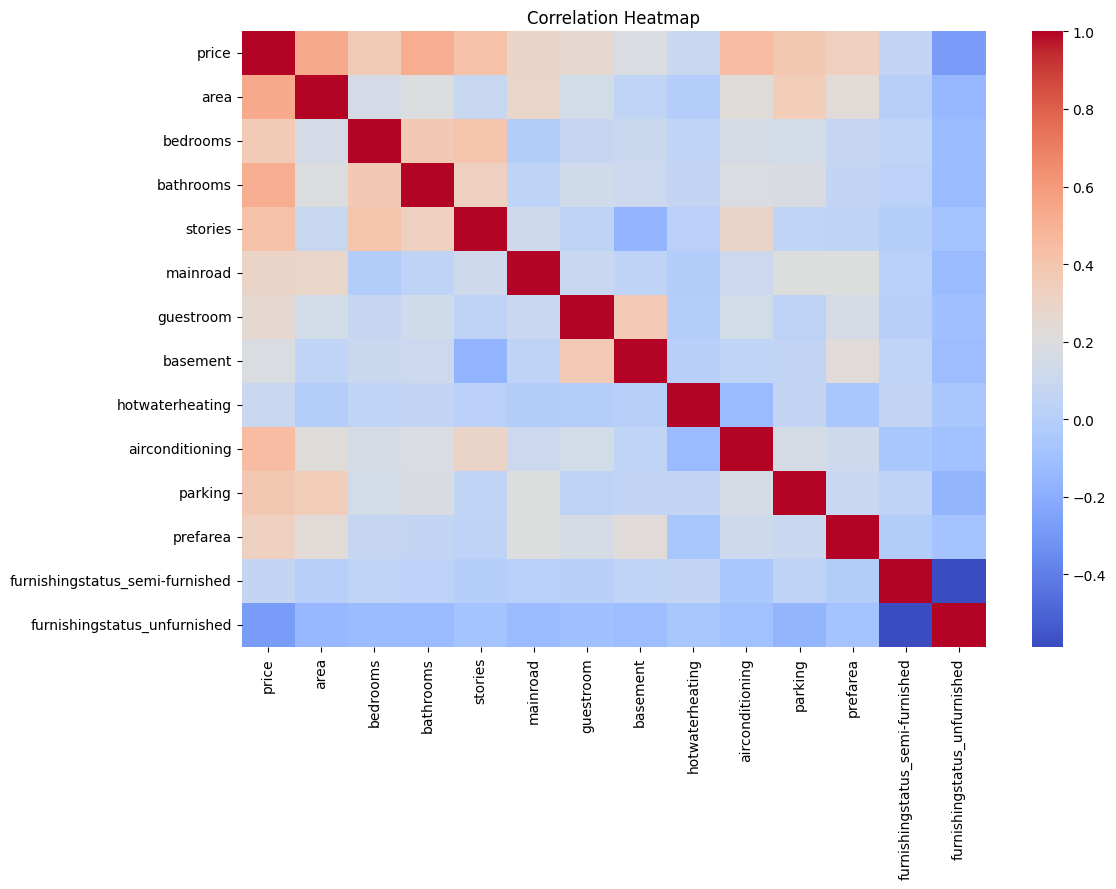

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=False, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()

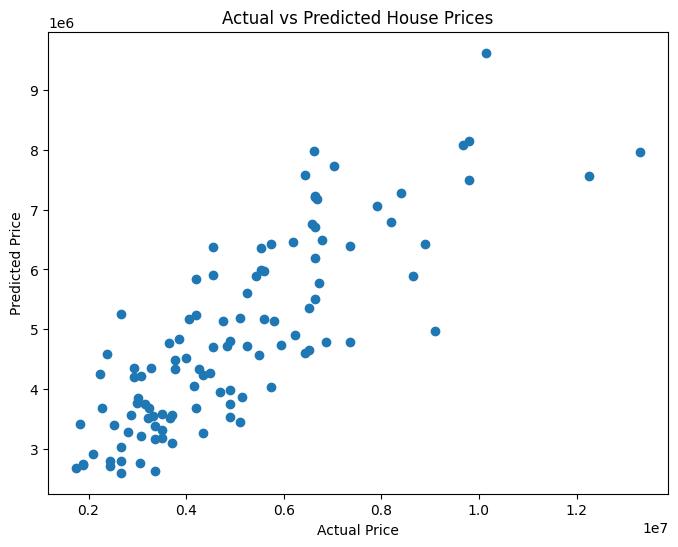

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png")
plt.show()